# EDA Part 2: Correlation & Data Storytelling

### Week 2 -Day 5

In this notebook, we will cover:

1. Produce **scatter plots** and **grouped box plots** for the most important variable pairs in the dataset.
2. Compute the **correlation matrix** and visualize it as an annotated **heatmap**.
3. Identify the two or three strongest relationships and state what they might mean for a future model.
4. Assemble the full EDA (**statistics, univariate, outliers, bivariate, correlation**) into one narrated notebook.
 > Note: Words written in bold represents key topics that were studied and covered during the day.

## Step 0 - Load Dataset & Setup data:

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [18]:
# Convert the dataset into a binary classification problem by creating a new target column(0 -> No heart disease, 1 -> Heart disease)
# convert the boolean "exang" feature to numeric values (0 and 1) for correlation and machine learning.
# and check the distribution of the new target classes.

# Note: I take these notes from claude:), and honestly, it was new info. and I learned a lot from it

df["target"] = (df["num"] > 0).astype(int)
df["exang"].isnull().sum()
df["exang"] = df["exang"].fillna(False).astype(int)
df["target"].value_counts()
df["exang"].value_counts()

exang
0    583
1    337
Name: count, dtype: int64

## Step 1 - Scatter plots and grouped box plots:

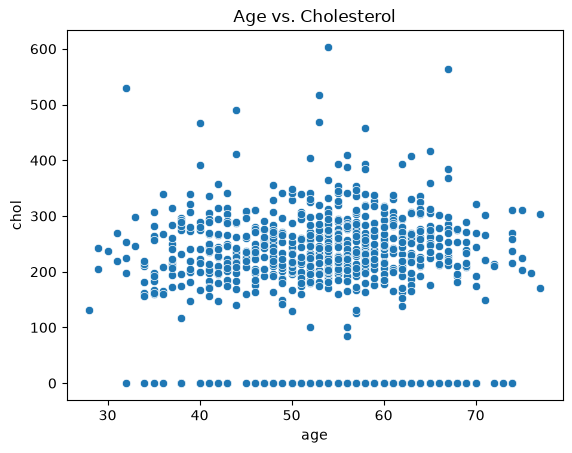

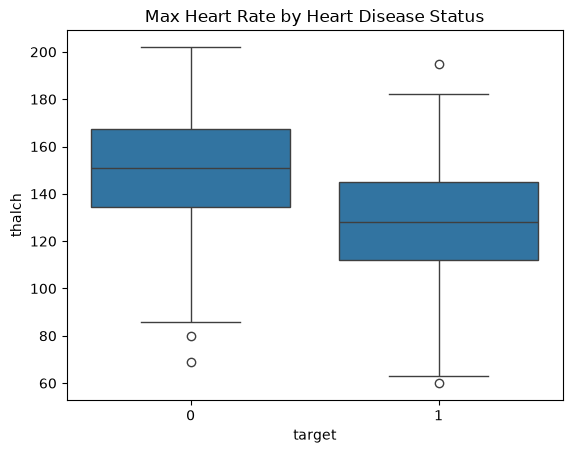

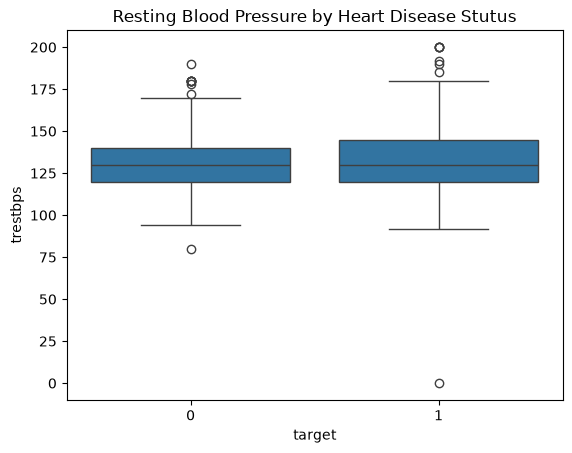

In [28]:
sns.scatterplot(data=df, x="age", y="chol")
plt.title("Age vs. Cholesterol")
plt.show()

sns.boxplot(data=df, x="target", y="thalch")
plt.title("Max Heart Rate by Heart Disease Status")
plt.show()

sns.boxplot(data=df, x="target", y="trestbps")
plt.title("Resting Blood Pressure by Heart Disease Stutus")
plt.show()

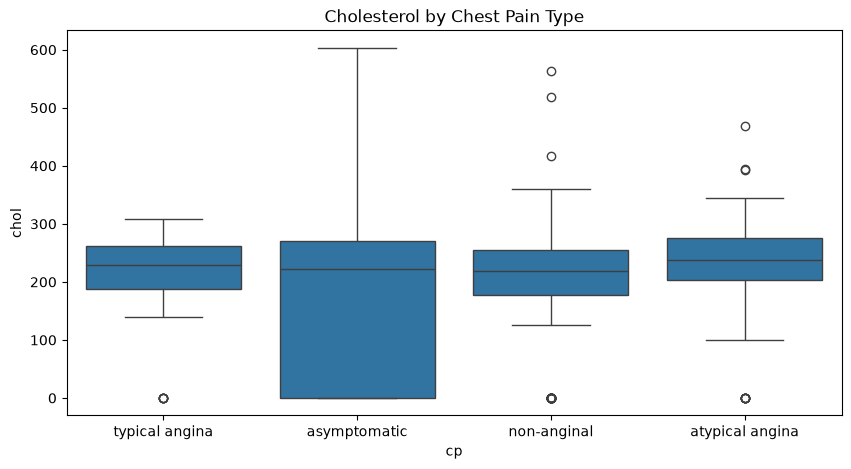

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="cp", y="chol")
plt.title("Cholesterol by Chest Pain Type")
plt.show()

## Step 2 - correlation matrix & heatmap:

In [33]:
numeric_df = df.drop(columns=["id"]).corr(numeric_only=True)
numeric_df

,age,trestbps,chol,thalch,exang,oldpeak,ca,num,target
age,1.000000,0.244253,-0.086234,-0.365778,0.160910,0.258243,0.370416,0.339596,0.282700
trestbps,0.244253,1.000000,0.092853,-0.104899,0.152328,0.161908,0.093705,0.122291,0.106233
chol,-0.086234,0.092853,1.000000,0.236121,-0.031898,0.047734,0.051606,-0.231547,-0.230583
thalch,-0.365778,-0.104899,0.236121,1.000000,-0.356439,-0.151174,-0.264094,-0.366265,-0.394503
exang,0.160910,0.152328,-0.031898,-0.356439,1.000000,0.391150,0.127385,0.350567,0.433605
oldpeak,0.258243,0.161908,0.047734,-0.151174,0.391150,1.000000,0.281817,0.443084,0.385528
ca,0.370416,0.093705,0.051606,-0.264094,0.127385,0.281817,1.000000,0.516216,0.455599
num,0.339596,0.122291,-0.231547,-0.366265,0.350567,0.443084,0.516216,1.000000,0.783387
target,0.282700,0.106233,-0.230583,-0.394503,0.433605,0.385528,0.455599,0.783387,1.000000


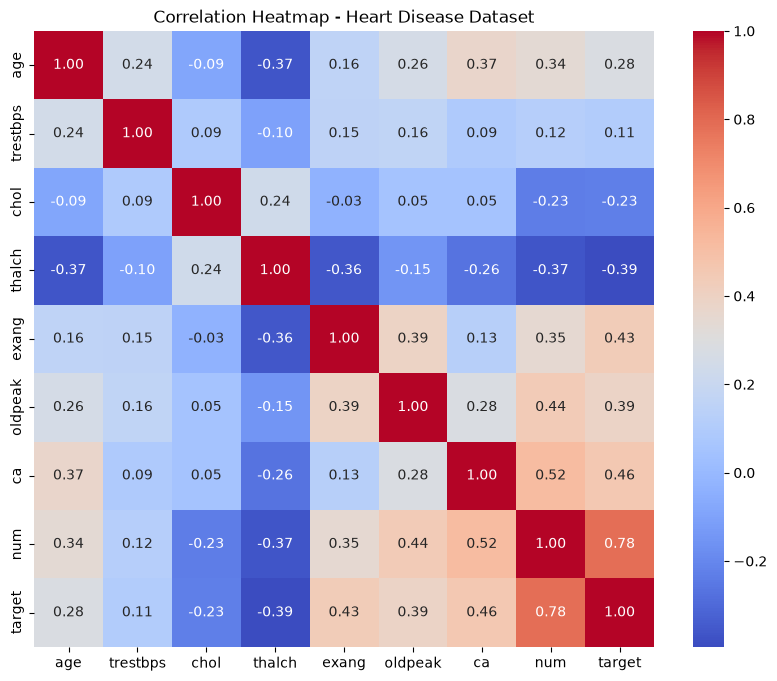

In [35]:
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Heart Disease Dataset")
plt.show()

## Step 3 - Identify the two or three strongest relationships:

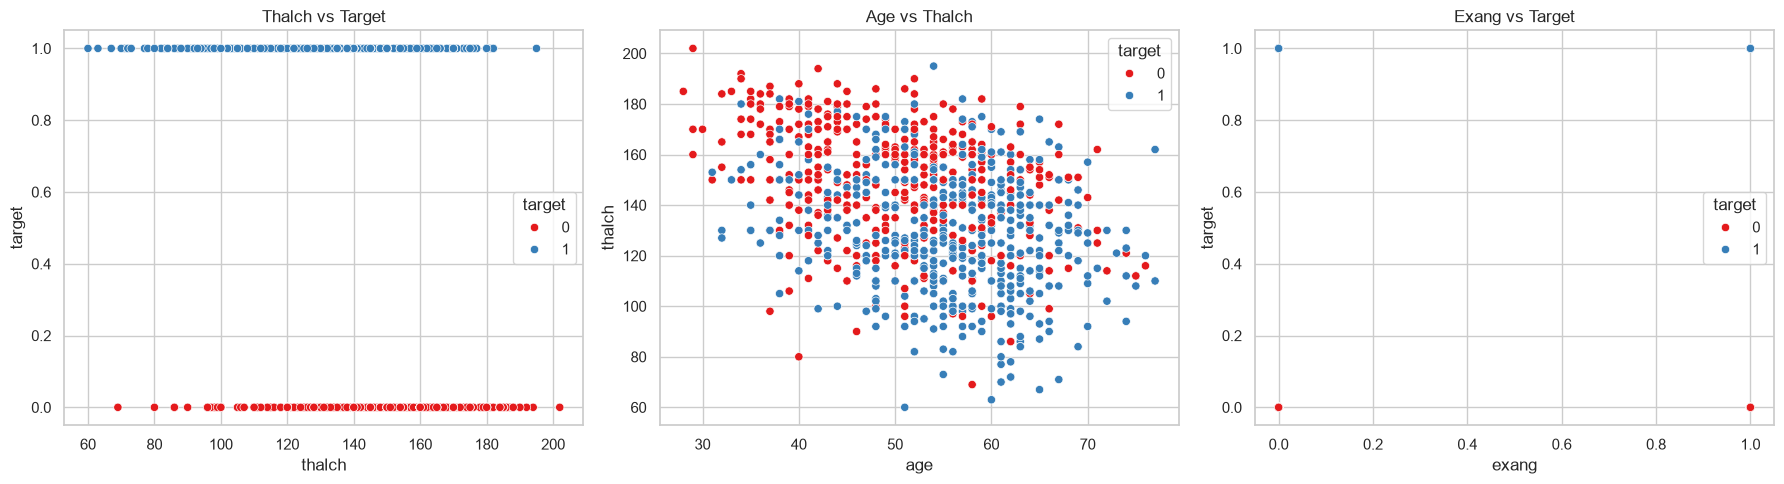

In [38]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="thalch", y="target", hue="target", palette="Set1", ax=axes[0])
axes[0].set_title("Thalch vs Target")

sns.scatterplot(data=df, x="age", y="thalch", hue="target", palette="Set1", ax=axes[1])
axes[1].set_title("Age vs Thalch")

sns.scatterplot(data=df, x="exang", y="target", hue="target", palette="Set1", ax=axes[2])
axes[2].set_title("Exang vs Target")

plt.tight_layout()
plt.show()

**Note:**
> The scatter plots highlight the strongest relationships in the dataset:

- **Thalach vs Target:** Patients with higher maximum heart rates "thalach" are more likely to belong to the positive heart disease class "target = 1". This suggests that **thalach** is an important feature for predicting heart disease.

- **Age vs Thalach:** A clear negative relationship is observed, where older patients generally have lower maximum heart rates. This follows the expected physiological trend and indicates that age is related to cardiovascular performance.

- **Exang vs Target:** The scatter plot shows a noticeable relationship between exercise-induced angina "exang" and the target variable. However, this pattern should be interpreted carefully, as it may reflect the dataset's encoding rather than a direct causal relationship.

**Conclusion:**  
**Conclusion:** The "**thalach**" appears to have the **strongest relationship** with the target and is likely to be one of the most useful predictors in a future machine learning classification model. 

## Step 4 - Complete EDA compilation in one notebook:

### 1. Descriptive Statistics: 
> for numeric columns, mean, median and std. 

### 2. Univariate Analysis

> histograms for age, chol, trestbps and thalach. / countplots for sex, cp, fbs, exang nad target. (In my dataset)


### 3. Outlier Detection
> for IQR.

### 4. Bivariate Analysis
> for scatter plots and grouped boxplots.

### 5. Correlation Analysis
> for heatmaps.

**Note: Every cell of above is explaied by markdown cell or by comments.**